## Setup: encoding the 48 election states


In [1]:
import math
import numpy as np
import pandas as pd
from itertools import permutations
from scipy.special import ndtr   # standard normal CDF

rng = np.random.default_rng(2026)

# Margin columns: 0 = A-vs-B, 1 = B-vs-C, 2 = C-vs-A.
# Sign convention: mAB > 0 means A beats B; mBC > 0 means B beats C;
# mCA > 0 means C beats A.
pos_pair = [('A','B'), ('B','C'), ('C','A')]   # (winner, loser) if margin > 0
neg_pair = [('B','A'), ('C','B'), ('A','C')]   # (winner, loser) if margin < 0
perms3 = list(permutations([0, 1, 2]))

def state_tuple(order, signs):
    return tuple(pos_pair[c] if signs[c] > 0 else neg_pair[c] for c in order)

def is_cyclic(state):
    wins = {c: set() for c in 'ABC'}
    for w, l in state:
        wins[w].add(l)
    return not any(wins[c] == {'A','B','C'} - {c} for c in 'ABC')

# Look-up tables over all 48 states, indexed by (magnitude order, sign pattern)
cyclic_lut = np.zeros((6, 8), dtype=bool)
tuple_to_code = {}
for oi, order in enumerate(perms3):
    for sc in range(8):
        signs = [1 if (sc >> k) & 1 else -1 for k in range(3)]
        st = state_tuple(order, signs)
        cyclic_lut[oi, sc] = is_cyclic(st)
        tuple_to_code[st] = (oi, sc)

# The six named states for the coalition A > B > C (verbatim from the post),
# with the chain "depth": how many rank-steps the lie must push the margins.
G1            = (('C','B'), ('B','A'), ('A','C'))
G2            = (('B','C'), ('A','B'), ('C','A'))
start1        = (('B','A'), ('A','C'), ('B','C'))
start2        = (('B','A'), ('B','C'), ('A','C'))
start3        = (('B','C'), ('B','A'), ('A','C'))
startBetrayal = (('B','C'), ('C','A'), ('A','B'))

named = [('start1', start1, 4), ('start2', start2, 3), ('start3', start3, 2),
         ('G1', G1, 1), ('betrayal start', startBetrayal, 2), ('G2', G2, 1)]
BURIAL_IDS = {0, 1, 2, 3}          # states manipulated by the C>B "burial" lie
GATE_IDS = {3, 5}                  # G1 and G2

state_id_lut = np.full((6, 8), -1, dtype=int)
for sid, (_, st, _) in enumerate(named):
    oi, sc = tuple_to_code[st]
    state_id_lut[oi, sc] = sid

_perm_arr = np.array(perms3)
_lut27 = np.zeros(27, dtype=int)
for i, row in enumerate(_perm_arr):
    _lut27[row[0]*9 + row[1]*3 + row[2]] = i

def classify(mAB, mBC, mCA):
    '''For arrays of margins, return (is_cyclic, state_id) where state_id
    indexes the six named states (-1 = any other state).'''
    M = np.stack([mAB, mBC, mCA], axis=1)
    order = np.argsort(np.abs(M), axis=1)
    oi = _lut27[order[:,0]*9 + order[:,1]*3 + order[:,2]]
    sc = (mAB > 0).astype(int) + 2*(mBC > 0).astype(int) + 4*(mCA > 0).astype(int)
    return cyclic_lut[oi, sc], state_id_lut[oi, sc]

def manip_delta(sid, mAB, mBC):
    '''delta* = minimal insincere-vote fraction (of the electorate) needed to
    push a state to its gate: half the gap between the closest two matchups,
    signed for whichever lie (burial vs. betrayal) the state calls for.
    NaN outside the six named states.'''
    delta = np.full(len(sid), np.nan)
    bur, bet = np.isin(sid, list(BURIAL_IDS)), (sid >= 4)
    delta[bur] = (mBC[bur] - mAB[bur]) / 2
    delta[bet] = (mAB[bet] - mBC[bet]) / 2
    return delta

## The cast of voter models


In [2]:
# Pairwise-vote vectors for the 6 rankings, in the order
# ABC, ACB, BAC, BCA, CAB, CBA  (so index 0 = the coalition's ranking)
Y_AB = np.array([ 1,  1, -1, -1,  1, -1], dtype=float)
Y_BC = np.array([ 1, -1,  1,  1, -1, -1], dtype=float)
Y_CA = np.array([-1, -1, -1,  1,  1,  1], dtype=float)

cultures = {}   # name -> dict(mAB, mBC, mCA [fractions], pool)

def add_ranking_culture(name, weights, n_voters, N, Y_AB=Y_AB, Y_BC=Y_BC, Y_CA=Y_CA):
    '''Cultures where we literally simulate n_voters ballots N times.'''
    counts = rng.multinomial(n_voters, weights, size=N)
    mAB, mBC, mCA = (counts @ Y_AB, counts @ Y_BC, counts @ Y_CA)
    # discard exact ties (rare, and merely a knife-edge technicality)
    keep = (mAB != 0) & (mBC != 0) & (mCA != 0)
    keep &= ((np.abs(mAB) != np.abs(mBC)) & (np.abs(mBC) != np.abs(mCA))
             & (np.abs(mAB) != np.abs(mCA)))
    cultures[name] = dict(
        mAB=mAB[keep]/n_voters, mBC=mBC[keep]/n_voters, mCA=mCA[keep]/n_voters,
        pool=counts[keep, 0]/n_voters)

N = 500_000
add_ranking_culture('IC, 1,001 voters',  np.full(6, 1/6), 1001,  N)
add_ranking_culture('IC, 10,001 voters', np.full(6, 1/6), 10001, N)

# Unlike a typical Condorcet ballot, Better Choices lets a voter cast an
# outright cyclic vote (A>B, B>C, C>A -- not a valid ranking, but a valid
# ballot here). Extend impartial culture from the 6 transitive rankings to
# all 8 possible tournaments over 3 candidates by adding the two cyclic
# profiles, each drawn with the same uniform weight as the other six.
Y_AB8 = np.append(Y_AB, [ 1, -1])
Y_BC8 = np.append(Y_BC, [ 1, -1])
Y_CA8 = np.append(Y_CA, [ 1, -1])
add_ranking_culture('IC, 8 profiles (incl. cyclic ballots)', np.full(8, 1/8), 1001, N,
                     Y_AB=Y_AB8, Y_BC=Y_BC8, Y_CA=Y_CA8)

# Mallows model: voters' rankings are drawn from a distribution centered around a reference ranking with a dispersion parameter phi.
phi = 0.97
w = phi ** np.array([0, 1, 1, 2, 2, 3]); w /= w.sum() # normalize to sum to 1
add_ranking_culture('Mallows (mild consensus)', w, 1001, N)

# IAC: society-wide ranking shares uniform on the simplex (Dirichlet(1,..,1));
# with many voters the margins are then determined by the shares.
P = rng.dirichlet(np.ones(6), size=2*N)
cultures['IAC'] = dict(mAB=P @ Y_AB, mBC=P @ Y_BC, mCA=P @ Y_CA, pool=P[:, 0])

# 2D spatial model: 3 Gaussian voter clusters, Gaussian candidates.
# Each matchup's vote share is an exact Gaussian half-plane measure
# (the perpendicular bisector of two candidates splits the plane).
K, tau, s, Nsp = 3, 1.0, 0.5, 400_000
cand    = rng.normal(0, 1,   size=(Nsp, 3, 2))
centers = rng.normal(0, tau, size=(Nsp, K, 2))
wts     = rng.dirichlet(np.ones(K), size=Nsp)

def spatial_margin(ci, cj):
    a = 2*(cj - ci)
    b = (cj**2).sum(axis=1) - (ci**2).sum(axis=1)
    z = (b[:, None] - np.einsum('nd,nkd->nk', a, centers)) \
        / (s * np.linalg.norm(a, axis=1)[:, None])
    return 2*(wts * ndtr(z)).sum(axis=1) - 1

A_, B_, C_ = cand[:, 0], cand[:, 1], cand[:, 2]
sp = dict(mAB=spatial_margin(A_, B_), mBC=spatial_margin(B_, C_),
          mCA=spatial_margin(C_, A_))

# The spatial pool (share of voters ranking A > B > C) has no simple formula,
# so estimate it by sampling voters -- but only for elections that land in
# one of the six states (the only place we need it).
_, sid_sp = classify(sp['mAB'], sp['mBC'], sp['mCA'])
pool = np.full(Nsp, np.nan)
hits, V = np.flatnonzero(sid_sp >= 0), 500
for lo in range(0, len(hits), 5000):
    idx = hits[lo:lo+5000]
    cid = (rng.random((len(idx), V, 1))
           > np.cumsum(wts[idx], axis=1)[:, None, :]).sum(axis=2)
    mu = np.take_along_axis(centers[idx], cid[:, :, None], axis=1)
    x = mu + rng.normal(0, s, size=(len(idx), V, 2))
    d2 = ((x[:, :, None, :] - cand[idx][:, None, :, :])**2).sum(axis=3)
    pool[idx] = ((d2[:,:,0] < d2[:,:,1]) & (d2[:,:,1] < d2[:,:,2])).mean(axis=1)
sp['pool'] = pool
cultures['2D spatial (3 factions)'] = sp

# Same voter geometry (centers, wts) as above, but now each candidate is
# literally a random voter: pick a faction (same inverse-CDF trick used for
# the pool below), then draw centers[faction] + N(0, s) -- the exact
# distribution real voters are drawn from -- instead of an independent
# N(0, 1) unrelated to the electorate.
cid_c = (rng.random((Nsp, 3, 1)) > np.cumsum(wts, axis=1)[:, None, :]).sum(axis=2)
mu_c  = np.take_along_axis(centers, cid_c[:, :, None], axis=1)
cand2 = mu_c + rng.normal(0, s, size=(Nsp, 3, 2))

A2_, B2_, C2_ = cand2[:, 0], cand2[:, 1], cand2[:, 2]
sp2 = dict(mAB=spatial_margin(A2_, B2_), mBC=spatial_margin(B2_, C2_),
           mCA=spatial_margin(C2_, A2_))

_, sid_sp2 = classify(sp2['mAB'], sp2['mBC'], sp2['mCA'])
pool2 = np.full(Nsp, np.nan)
hits2 = np.flatnonzero(sid_sp2 >= 0)
for lo in range(0, len(hits2), 5000):
    idx = hits2[lo:lo+5000]
    cid = (rng.random((len(idx), V, 1))
           > np.cumsum(wts[idx], axis=1)[:, None, :]).sum(axis=2)
    mu = np.take_along_axis(centers[idx], cid[:, :, None], axis=1)
    x = mu + rng.normal(0, s, size=(len(idx), V, 2))
    d2 = ((x[:, :, None, :] - cand2[idx][:, None, :, :])**2).sum(axis=3)
    pool2[idx] = ((d2[:,:,0] < d2[:,:,1]) & (d2[:,:,1] < d2[:,:,2])).mean(axis=1)
sp2['pool'] = pool2
cultures['2D spatial (endogenous candidates)'] = sp2

print('simulated cultures:', ', '.join(cultures))

simulated cultures: IC, 1,001 voters, IC, 10,001 voters, IC, 8 profiles (incl. cyclic ballots), Mallows (mild consensus), IAC, 2D spatial (3 factions), 2D spatial (endogenous candidates)


## Question 1: How often do manipulable states occur at all?


In [3]:
rows = []
for name, cu in cultures.items():
    cyc, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    rows.append({
        'model': name,
        'P(cycle)':          f"{cyc.mean()*100:.2f}%",
        'P(at a gate)':      f"{np.isin(sid, list(GATE_IDS)).mean()*100:.3f}%",
        'P(any of the six)': f"{(sid >= 0).mean()*100:.2f}%",
    })
pd.DataFrame(rows).set_index('model')

,P(cycle),P(at a gate),P(any of the six)
model,,,
"IC, 1,001 voters",8.25%,1.393%,9.74%
"IC, 10,001 voters",8.65%,1.482%,9.84%
"IC, 8 profiles (incl. cyclic ballots)",24.98%,4.150%,12.46%
Mallows (mild consensus),5.88%,0.920%,14.13%
IAC,6.25%,1.047%,9.32%
2D spatial (3 factions),0.11%,0.021%,10.30%
2D spatial (endogenous candidates),0.15%,0.030%,10.10%


In [4]:
# "Shadow win" check: among states with a Condorcet winner W, the third
# candidate F (who beats the Condorcet loser L but loses to W) makes the
# state burial-vulnerable iff F's win over L is wider than W's win over F --
# see the "Burial vulnerability" theorem. By state count this is exactly
# 18/36 = 50% of CW states. Here we measure the *simulated* rate instead.
def cw_and_vulnerable(mAB, mBC, mCA):
    is_cw_A = (mAB > 0) & (mCA < 0)   # A beats B and A beats C
    is_cw_B = (mBC > 0) & (mAB < 0)   # B beats C and B beats A
    is_cw_C = (mCA > 0) & (mBC < 0)   # C beats A and C beats B
    has_cw = is_cw_A | is_cw_B | is_cw_C

    vulnerable = np.zeros(len(mAB), dtype=bool)
    # For each CW, F/L are settled by the one matchup not involving W;
    # vulnerable iff F's win over L outranks W's win over F.
    vulnerable[is_cw_A] = np.where(mBC[is_cw_A] > 0,
                                    mBC[is_cw_A] > mAB[is_cw_A],    # F=B, L=C
                                    -mBC[is_cw_A] > -mCA[is_cw_A])  # F=C, L=B
    vulnerable[is_cw_B] = np.where(mCA[is_cw_B] > 0,
                                    mCA[is_cw_B] > mBC[is_cw_B],    # F=C, L=A
                                    -mCA[is_cw_B] > -mAB[is_cw_B])  # F=A, L=C
    vulnerable[is_cw_C] = np.where(mAB[is_cw_C] > 0,
                                    mAB[is_cw_C] > mCA[is_cw_C],    # F=A, L=B
                                    -mAB[is_cw_C] > -mBC[is_cw_C])  # F=B, L=A
    return has_cw, vulnerable

rows = []
for name, cu in cultures.items():
    has_cw, vulnerable = cw_and_vulnerable(cu['mAB'], cu['mBC'], cu['mCA'])
    rows.append({
        'model': name,
        'P(CW state)':                  f"{has_cw.mean()*100:.2f}%",
        'P(burial-vulnerable | CW)':    f"{vulnerable[has_cw].mean()*100:.2f}%",
        'state-count baseline':         "50.00%",
    })
pd.DataFrame(rows).set_index('model')


,P(CW state),P(burial-vulnerable | CW),state-count baseline
model,,,
"IC, 1,001 voters",91.75%,50.09%,50.00%
"IC, 10,001 voters",91.35%,50.03%,50.00%
"IC, 8 profiles (incl. cyclic ballots)",75.02%,49.93%,50.00%
Mallows (mild consensus),94.12%,49.96%,50.00%
IAC,93.75%,49.97%,50.00%
2D spatial (3 factions),99.89%,61.75%,50.00%
2D spatial (endogenous candidates),99.85%,60.30%,50.00%


In [5]:
# Why do the spatial models land above the 50% baseline? Hypothesis: the
# Condorcet loser L tends to be the most "extreme" candidate (farthest from
# the electorate's center), while F is comparatively central -- so F crushes
# L, but W and F, both plausible centrists, fight over a much closer margin.
# Test this directly using the candidate/voter coordinates already simulated
# for the two spatial cultures.
electorate_center = np.einsum('nk,nkd->nd', wts, centers)   # weighted mean of the 3 clusters

def cw_identify(mAB, mBC, mCA):
    '''Candidate indices (0=A,1=B,2=C) for W, F, L at each row (-1 = no CW).
    Mirrors cw_and_vulnerable's branches, but returns identities, not just
    the vulnerability flag.'''
    is_cw_A = (mAB > 0) & (mCA < 0)
    is_cw_B = (mBC > 0) & (mAB < 0)
    is_cw_C = (mCA > 0) & (mBC < 0)
    has_cw = is_cw_A | is_cw_B | is_cw_C

    w_idx = np.select([is_cw_A, is_cw_B, is_cw_C], [0, 1, 2], default=-1)
    f_idx = np.full(len(mAB), -1)
    l_idx = np.full(len(mAB), -1)

    bc_pos, bc_neg = is_cw_A & (mBC > 0), is_cw_A & (mBC <= 0)
    f_idx[bc_pos], l_idx[bc_pos] = 1, 2   # F=B, L=C
    f_idx[bc_neg], l_idx[bc_neg] = 2, 1   # F=C, L=B

    ca_pos, ca_neg = is_cw_B & (mCA > 0), is_cw_B & (mCA <= 0)
    f_idx[ca_pos], l_idx[ca_pos] = 2, 0   # F=C, L=A
    f_idx[ca_neg], l_idx[ca_neg] = 0, 2   # F=A, L=C

    ab_pos, ab_neg = is_cw_C & (mAB > 0), is_cw_C & (mAB <= 0)
    f_idx[ab_pos], l_idx[ab_pos] = 0, 1   # F=A, L=B
    f_idx[ab_neg], l_idx[ab_neg] = 1, 0   # F=B, L=A

    return has_cw, w_idx, f_idx, l_idx

def check_extremity(name, cand_arr):
    cu = cultures[name]
    has_cw, vulnerable = cw_and_vulnerable(cu['mAB'], cu['mBC'], cu['mCA'])
    _, w_idx, f_idx, l_idx = cw_identify(cu['mAB'], cu['mBC'], cu['mCA'])

    dist = np.linalg.norm(cand_arr - electorate_center[:, None, :], axis=2)  # (N, 3)
    idx = np.arange(len(cu['mAB']))
    d_w, d_f, d_l = (dist[idx, np.clip(k, 0, 2)] for k in (w_idx, f_idx, l_idx))

    m = has_cw   # restrict everything below to CW states
    l_farther = d_l[m] > d_f[m]   # is the Condorcet loser farther out than F?
    return {
        'model': name,
        'median dist to center: W / F / L':
            f"{np.median(d_w[m]):.3f} / {np.median(d_f[m]):.3f} / {np.median(d_l[m]):.3f}",
        'P(L farther than F | CW)': f"{l_farther.mean()*100:.1f}%",
        'P(vulnerable | L farther)':     f"{vulnerable[m][l_farther].mean()*100:.1f}%",
        'P(vulnerable | L not farther)': f"{vulnerable[m][~l_farther].mean()*100:.1f}%",
    }

pd.DataFrame([
    check_extremity('2D spatial (3 factions)', cand),
    check_extremity('2D spatial (endogenous candidates)', cand2),
]).set_index('model')


,median dist to center: W / F / L,P(L farther than F | CW),P(vulnerable | L farther),P(vulnerable | L not farther)
model,,,,
2D spatial (3 factions),0.858 / 1.434 / 2.118,95.1%,64.3%,12.5%
2D spatial (endogenous candidates),0.566 / 0.920 / 1.385,91.9%,64.5%,12.2%


## Question 2: Could you even *know* you're in a manipulable state?


In [6]:
rows = []
for name, cu in cultures.items():
    M = np.abs(np.stack([cu['mAB'], cu['mBC'], cu['mCA']], axis=1))
    M.sort(axis=1)                                  # |m1| <= |m2| <= |m3|
    eps = np.minimum(M[:,0], np.minimum(M[:,1]-M[:,0], M[:,2]-M[:,1]))
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    g = np.isin(sid, list(GATE_IDS))                # condition on gate states
    rows.append({
        'model': name,
        'closest matchup': f"{np.median(M[g,0])*100:.2f}%",
        'middle matchup':  f"{np.median(M[g,1])*100:.2f}%",
        'widest matchup':  f"{np.median(M[g,2])*100:.2f}%",
        'identification radius': f"{np.median(eps[g])*100:.2f}%",
        'hidden below 3.5% poll noise': f"{(eps[g] < 0.035).mean()*100:.0f}%",
        'hidden below 1% aggregate':    f"{(eps[g] < 0.01).mean()*100:.0f}%",
    })
pd.DataFrame(rows).set_index('model')

,closest matchup,middle matchup,widest matchup,identification radius,hidden below 3.5% poll noise,hidden below 1% aggregate
model,,,,,,
"IC, 1,001 voters",0.50%,1.30%,2.70%,0.30%,100%,99%
"IC, 10,001 voters",0.13%,0.41%,0.85%,0.07%,100%,100%
"IC, 8 profiles (incl. cyclic ballots)",0.90%,2.10%,4.10%,0.40%,100%,90%
Mallows (mild consensus),0.50%,1.30%,2.90%,0.30%,100%,99%
IAC,4.35%,12.86%,28.85%,2.18%,69%,26%
2D spatial (3 factions),1.63%,6.08%,13.25%,0.84%,90%,60%
2D spatial (endogenous candidates),1.13%,3.65%,9.38%,0.53%,97%,74%


In [7]:
def bracket(cu, sid_target, state):
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    mask = (sid == sid_target)
    M = np.abs(np.stack([cu['mAB'], cu['mBC'], cu['mCA']], axis=1))[mask]
    M.sort(axis=1)
    labels = [f"{w}→{l}" for w, l in state]
    p1, p2, p3 = (np.median(M[:, k])*100 for k in range(3))
    delta = manip_delta(sid, cu['mAB'], cu['mBC'])[mask]
    manip_cost = np.median(delta)*100 if mask.any() else float('nan')
    pool_pct = np.median(cu['pool'][mask])*100 if mask.any() else float('nan')
    bracket_str = f"⟨{labels[0]} ({p1:.2f}%) | {labels[1]} ({p2:.2f}%) | {labels[2]} ({p3:.2f}%)⟩"
    return bracket_str, pool_pct, manip_cost

rows = []
for name, cu in cultures.items():
    for sid, (label, state, depth) in enumerate(named):
        bracket_str, pool_pct, manip_cost = bracket(cu, sid, state)
        rows.append({
            'model': name,
            'state': label,
            'median margins': bracket_str,
            'median manipulation cost': f"{manip_cost:.2f}%",
            'median A≻B≻C pool': f"{pool_pct:.2f}%",
        })
pd.DataFrame(rows).set_index(['model', 'state'])

median margins  \
model                                 state                                                          
IC, 1,001 voters                      start1             ⟨B→A (0.90%) | A→C (2.50%) | B→C (4.50%)⟩   
                                      start2             ⟨B→A (0.70%) | B→C (2.50%) | A→C (4.10%)⟩   
                                      start3             ⟨B→C (0.70%) | B→A (1.70%) | A→C (3.30%)⟩   
                                      G1                 ⟨C→B (0.50%) | B→A (1.30%) | A→C (2.70%)⟩   
                                      betrayal start     ⟨B→C (0.50%) | C→A (1.30%) | A→B (2.90%)⟩   
                                      G2                 ⟨B→C (0.50%) | A→B (1.30%) | C→A (2.70%)⟩   
IC, 10,001 voters                     start1             ⟨B→A (0.31%) | A→C (0.81%) | B→C (1.39%)⟩   
                                      start2             ⟨B→A (0.27%) | B→C (0.75%) | A→C (1.27%)⟩   
                                      start3             ⟨B→C (0.25%) | B→A (0.55%) | A→C (1.01%)⟩   
                                      G1                 ⟨C→B (0.13%) | B→A (0.41%) | A→C (0.85%)⟩   
                                      betrayal start     ⟨B→C (0.13%) | C→A (0.41%) | A→B (0.85%)⟩   
                                      G2                 ⟨B→C (0.13%) | A→B (0.41%) | C→A (0.87%)⟩   
IC, 8 profiles (incl. cyclic ballots) start1             ⟨B→A (0.90%) | A→C (2.10%) | B→C (4.10%)⟩   
                                      start2             ⟨B→A (0.90%) | B→C (2.10%) | A→C (4.10%)⟩   
                                      start3             ⟨B→C (0.90%) | B→A (2.10%) | A→C (4.10%)⟩   
                                      G1                 ⟨C→B (0.90%) | B→A (2.10%) | A→C (4.10%)⟩   
                                      betrayal start     ⟨B→C (0.90%) | C→A (2.10%) | A→B (4.10%)⟩   
                                      G2                 ⟨B→C (0.90%) | A→B (2.30%) | C→A (4.10%)⟩   
Mallows (mild consensus)              start1             ⟨B→A (1.10%) | A→C (3.10%) | B→C (5.29%)⟩   
                                      start2             ⟨B→A (0.90%) | B→C (3.10%) | A→C (4.90%)⟩   
                                      start3             ⟨B→C (0.90%) | B→A (1.90%) | A→C (3.50%)⟩   
                                      G1                 ⟨C→B (0.50%) | B→A (1.30%) | A→C (2.90%)⟩   
                                      betrayal start     ⟨B→C (0.50%) | C→A (1.30%) | A→B (3.10%)⟩   
                                      G2                 ⟨B→C (0.50%) | A→B (1.30%) | C→A (2.70%)⟩   
IAC                                   start1          ⟨B→A (13.02%) | A→C (31.27%) | B→C (50.14%)⟩   
                                      start2          ⟨B→A (13.04%) | B→C (31.53%) | A→C (50.18%)⟩   
                                      start3          ⟨B→C (12.92%) | B→A (22.74%) | A→C (40.75%)⟩   
                                      G1               ⟨C→B (4.38%) | B→A (12.88%) | A→C (28.75%)⟩   
                                      betrayal start   ⟨B→C (4.39%) | C→A (13.08%) | A→B (29.18%)⟩   
                                      G2               ⟨B→C (4.30%) | A→B (12.84%) | C→A (28.97%)⟩   
2D spatial (3 factions)               start1          ⟨B→A (26.39%) | A→C (63.35%) | B→C (86.36%)⟩   
                                      start2          ⟨B→A (32.86%) | B→C (71.24%) | A→C (89.69%)⟩   
                                      start3          ⟨B→C (16.65%) | B→A (19.89%) | A→C (31.34%)⟩   
                                      G1                ⟨C→B (2.31%) | B→A (5.68%) | A→C (12.30%)⟩   
                                      betrayal start    ⟨B→C (1.30%) | C→A (5.88%) | A→B (10.49%)⟩   
                                      G2                ⟨B→C (1.44%) | A→B (6.51%) | C→A (14.16%)⟩   
2D spatial (endogenous candidates)    start1          ⟨B→A (15.41%) | A→C (39.47%) | B→C (58.42%)⟩   
                                      start2          ⟨B→A (17.36%) | B→C (42.68%) | A→C (66.26%)⟩   
    

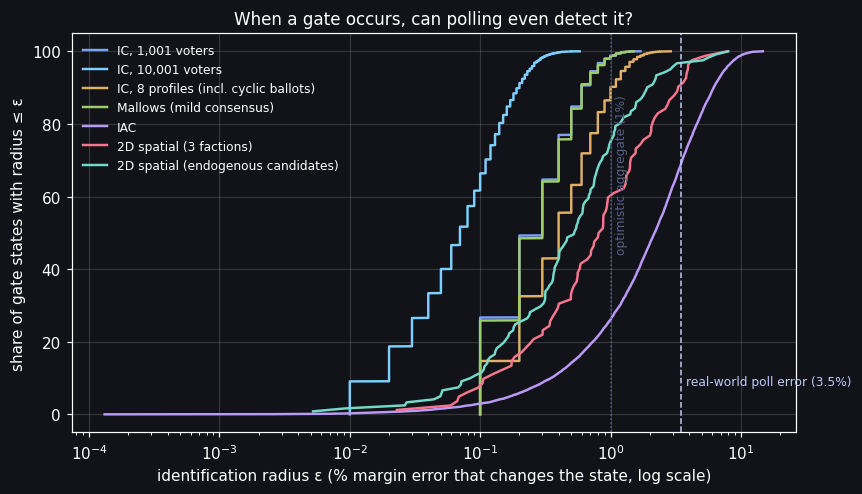

In [8]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=110)
fig.patch.set_facecolor('#111318'); ax.set_facecolor('#111318')
colors = ['#7aa2f7', '#7dcfff', '#e0af68', '#9ece6a', '#bb9af7', '#f7768e', '#73daca']
for (name, cu), col in zip(cultures.items(), colors):
    M = np.abs(np.stack([cu['mAB'], cu['mBC'], cu['mCA']], axis=1)); M.sort(axis=1)
    eps = np.minimum(M[:,0], np.minimum(M[:,1]-M[:,0], M[:,2]-M[:,1]))
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    e = np.sort(eps[np.isin(sid, list(GATE_IDS))])
    ax.plot(e*100, np.arange(1, len(e)+1)/len(e)*100, color=col, lw=1.6, label=name)
ax.axvline(3.5, color='#c0caf5', ls='--', lw=1)
ax.text(3.8, 8, 'real-world poll error (3.5%)', color='#c0caf5', fontsize=8)
ax.axvline(1.0, color='#565f89', ls=':', lw=1)
ax.text(1.08, 45, 'optimistic aggregate (1%)', color='#565f89', fontsize=8, rotation=90)
ax.set_xscale('log')
ax.set_xlabel('identification radius ε (% margin error that changes the state, log scale)')
ax.set_ylabel('share of gate states with radius ≤ ε')
ax.set_title('When a gate occurs, can polling even detect it?', fontsize=11)
ax.legend(frameon=False, fontsize=8, loc='upper left')
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

## Question 3: How many voters would have to lie?


In [9]:
rows = []
for name, cu in cultures.items():
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    delta = manip_delta(sid, cu['mAB'], cu['mBC'])
    six, gates = (sid >= 0), np.isin(sid, list(GATE_IDS))
    ratio = np.divide(delta, cu['pool'],
                      out=np.full_like(delta, np.inf), where=cu['pool'] > 0)
    rows.append({
        'model': name,
        'median cost, at gates': f"{np.median(delta[gates])*100:.2f}%",
        'median cost, any of six': f"{np.median(delta[six])*100:.1f}%",
        'median share of coalition needed': f"{np.median(ratio[six])*100:.0f}%",
        'P(coalition big enough)': f"{(ratio[six] <= 1).mean()*100:.0f}%",
    })
pd.DataFrame(rows).set_index('model')

,"median cost, at gates","median cost, any of six",median share of coalition needed,P(coalition big enough)
model,,,,
"IC, 1,001 voters",0.30%,1.7%,10%,100%
"IC, 10,001 voters",0.10%,0.5%,3%,100%
"IC, 8 profiles (incl. cyclic ballots)",0.50%,1.3%,10%,100%
Mallows (mild consensus),0.30%,2.4%,14%,100%
IAC,3.22%,22.2%,120%,41%
2D spatial (3 factions),1.76%,53.3%,238%,10%
2D spatial (endogenous candidates),0.96%,34.4%,154%,27%


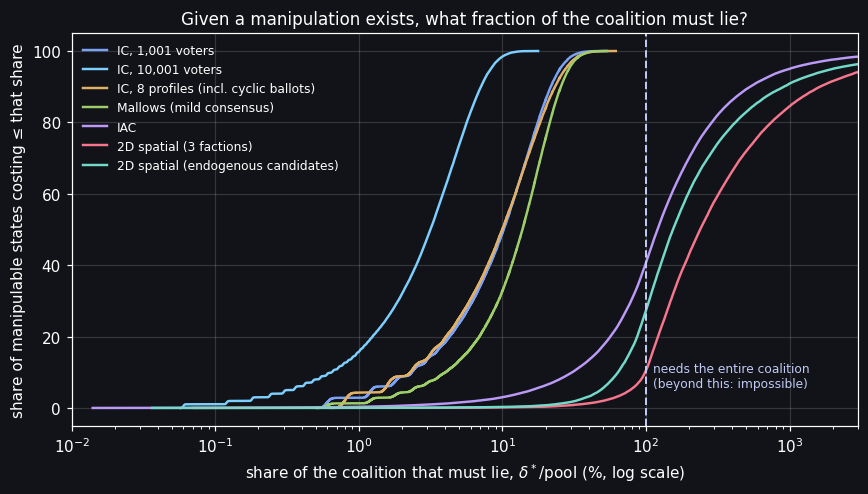

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=110)
fig.patch.set_facecolor('#111318'); ax.set_facecolor('#111318')
for (name, cu), col in zip(cultures.items(), colors):
    _, sid = classify(cu['mAB'], cu['mBC'], cu['mCA'])
    delta = manip_delta(sid, cu['mAB'], cu['mBC'])
    six = (sid >= 0)
    # ratio = share of the *coalition* (not the electorate) that must lie;
    # a pool of 0 makes the manipulation impossible outright (ratio = inf).
    ratio = np.divide(delta, cu['pool'],
                      out=np.full_like(delta, np.inf), where=cu['pool'] > 0)
    r = np.sort(ratio[six])
    n = len(r)
    finite = np.isfinite(r)
    # CDF denominator is the full count `n`, so curves that hit an infeasible
    # (infinite-ratio) state simply stop short of 100% on the y-axis.
    ax.plot(r[finite]*100, (np.flatnonzero(finite)+1) * 100 / n, color=col, lw=1.6, label=name)
ax.axvline(100, color='#c0caf5', ls='--', lw=1.3)
ax.text(112, 6, 'needs the entire coalition\n(beyond this: impossible)', color='#c0caf5', fontsize=8)
ax.set_xscale('log')
ax.set_xlim(1e-2, 3000)   # a rare tail of extreme outliers (tiny pools) runs off-chart
ax.set_xlabel(r'share of the coalition that must lie, $\delta^*/\mathrm{pool}$ (%, log scale)')
ax.set_ylabel('share of manipulable states costing ≤ that share')
ax.set_title('Given a manipulation exists, what fraction of the coalition must lie?', fontsize=11)
ax.legend(frameon=False, fontsize=8, loc='upper left')
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()